# Learning Summary Statistics from Images

This notebook demonstrates how a convolutional neural network (CNN) can learn a low-dimensional representation of a two-dimensional image for use in an SBI workflow.

The simulator was provided by Niklas Schwan of the Helmholtz Centre for Infection Research. It is an agent-based model of interactions between normal and tumor cells. Because its likelihood is not readily available, it is well suited to simulation-based inference.

The simulator can be found [in this GitLab repository](https://gitlab.com/NiklasSchwan/twocellinteractions).

## Two-cell interaction simulator

We simulate interactions between normal and tumor cells over time under a simplified set of initial conditions.

The inferred parameters are the mean velocities of normal and tumor cells, $v_N$ and $v_T$, and their cell-cycle durations, $w_N$ and $w_T$. A cell-cycle duration is the simulated time required for one cycle of growth and division.

We hold the following quantities fixed:

- the spatial grid;
- the initial positions of normal and tumor cells;
- the radius of the reaction volume;
- the relative phase width;
- the simulation duration and time step; and
- the movement persistence of both cell types.

The simulator is written in C++ and invoked from Python with the `subprocess` module. This illustrates how SBI can use an external simulator that is not written in Python; a binding library such as pybind11 would be another option.

The Python interface is provided in `simulators/cell_growth.py`. It accepts a parameter tensor or array

```python
pvec = torch.tensor([w_T, v_T, w_N, v_N])
```

and a `sim_type` argument: `"observables"`, `"image"`, or `"both"`.

- If `image` is chosen, then the output is the image of the configuration after 100 hours of interaction. This will be useful for the embedding network. A single simulation produces an RGB tensor with shape $(65,65,3)$ and `float32` pixel intensities normalized to the interval $[0,1]$.

- If `observables` is chosen, then the output contains the mean positions of the normal- and tumor-cell clusters, the 75% confining radius for both cell types, and the total number of normal and tumor cells. These summary statistics are calculated from the final configuration after 100 hours of interaction and are considered informative by experts in the field.

- If `both` is chosen, the result contains both the image and the observables.


In [1]:
import os
import sys
from pathlib import Path

import torch
import matplotlib.pyplot as plt

# Locate the repository independently of the Jupyter working directory.
repo_candidates = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next((path for path in repo_candidates
                  if (path / "notebooks" / "simulators").is_dir()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not locate the sbi_intro repository root.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from notebooks.simulators.cell_growth import simulator
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import process_prior, process_simulator
from sbi.utils.simulation_utils import simulate_for_sbi
from sbi.neural_nets import posterior_nn
from sbi.neural_nets.embedding_nets import CNNEmbedding
from sbi.inference import NPE
from sbi.analysis.plot import pairplot
from sbi.utils.sbiutils import seed_all_backends
seed_all_backends(24)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
num_cpus = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1))
workers = min(64, num_cpus)
print(f"Using {device} for training and {workers} simulation workers.")

%matplotlib inline

Using cuda:0 for training and 64 simulation workers.


Inspect the simulator's interface:

In [2]:
help(simulator)

Help on function simulator in module notebooks.simulators.cell_growth:

simulator(pvec, sim_type='observables', seed=None)
    The simulator TwoCell has 16 inputs.
    pvec can be any combination of the parameters listed.
    pvec : torch.tensor, np.array, list
    sim_type: one of ["observables", "image", "both"]
    seed: optional integer seed; use None for an independent random seed



To understand the available outputs, first inspect the fixed simulator settings:

```python
params["general"]["random_seed"] = seed
params["general"]["grid_constant"] = 5
params["general"]["radius_volume"] = 160
params["general"]["simulation_duration"] = 100
params["general"]["time_step"] = 0.002
params["general"]["width_phases"] = 0.5

params["tumor"]["initial_number"] = 1
params["tumor"]["cycle_duration"] = pvec[0]
params["tumor"]["mean_velocity"] = pvec[1]
params["tumor"]["persistence_polarity"] = 1.5
params["tumor"]["initial_position"] = 137312

params["normal"]["initial_number"] = 5
params["normal"]["cycle_duration"] = pvec[2]
params["normal"]["mean_velocity"] = pvec[3]
params["normal"]["persistence_polarity"] = 1.5
params["normal"]["initial_position"] = 133087
```

These values keep the example manageable, although additional parameters could also be inferred. By default, each call uses an independent random seed so that the training data include the simulator's stochastic variability. We pass an explicit seed only when two output representations must describe the same synthetic observation.

### Image
Let's run the simulator with the output set as the image of the final configuration of the system after 100 hours of interaction.

In [3]:
%%time 
# Avoid cell cycles shorter than 7 hours: rapid reproduction greatly increases
# the computation required to simulate the full 100-hour duration.
pvec = torch.tensor([10, 0.02, 13, 0.06])
data = simulator(pvec, sim_type="image")
data.shape

CPU times: user 5.46 ms, sys: 1.77 ms, total: 7.23 ms
Wall time: 1.17 s


torch.Size([65, 65, 3])

Display the simulated image with Matplotlib:

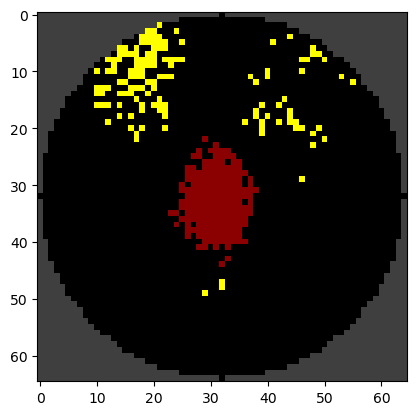

In [4]:
plt.figure()
plt.imshow(data)
plt.show()

In this image, red pixels represent tumor cells and yellow normal cells. You can play around with the inputs of `pvec` to see the outcomes of the simulation.

The underlying simulation is three-dimensional, but the displayed image is its projection onto the $xy$ plane. Each pixel is colored according to its dominant cell type; empty pixels are black. We use this two-dimensional representation to keep the example simple.

### Observables

Let's run a simulation with `sim_type="observables"`. Because the parameter order is $[w_T, v_T, w_N, v_N]$, this example sets the tumor-cell cycle duration and speed to $w_T=14\,\mathrm{h}$ and $v_T=0.02\,\mu\mathrm{m}/\mathrm{min}$, and the normal-cell values to $w_N=24\,\mathrm{h}$ and $v_N=0.03\,\mu\mathrm{m}/\mathrm{min}$.

In [5]:
pvec = torch.tensor([14, 0.02, 24, 0.03])
data = simulator(pvec, sim_type="observables")
data.shape

torch.Size([14])

The output is a 14-element tensor: mean positions of the normal and tumor cells along $x$, $y$, and $z$ (indices 0–5); 75% confining radii for both cell types along each axis (indices 6–11); and the numbers of normal and tumor cells (indices 12 and 13).

In [6]:
def print_summary(data):
    data = data.numpy()
    mean_pos_N = data[0:3]
    mean_pos_T = data[3:6]
    conf_radius_N = data[6:9]
    conf_radius_T = data[9:12]
    num_normal_cells = data[12]
    num_tumor_cells = data[13]
    
    print(f"{mean_pos_N=}\n{mean_pos_T=}\n{conf_radius_N=}\n{conf_radius_T=}\n{num_normal_cells=}\n{num_tumor_cells=}")

print_summary(data)

mean_pos_N=array([14., 15., 16.])
mean_pos_T=array([13., 18.,  0.])
conf_radius_N=array([25.4951, 26.1725, 26.1725])
conf_radius_T=array([25.4951, 38.4708, 38.4187])
num_normal_cells=np.float64(81.0)
num_tumor_cells=np.float64(69.0)


### Both output types

The simulator can return both output types at once, although this notebook treats them separately.

## SBI workflow

One approach is to use the expert-designed `observables` as summary statistics and train a masked autoregressive flow to estimate the posterior. However, these summaries may omit information relevant to inference. An alternative is to train a CNN jointly with the posterior estimator so that it learns a compact representation of the image. This learned representation plays the role of summary statistics in the SBI workflow.

We first infer the four parameters from the supplied observables. We then infer them from images using a CNN embedding and compare the two approaches.

### Generating training data from the observables

First, generate the training data. A precomputed dataset is provided, but the simulation code is included so that the data can also be generated from scratch.

Define a helper that initializes the SBI workflow:

In [7]:
def initialize_sbi(low, high,sim_type):
    prior = BoxUniform(
        low=low, high=high
    )
    print("Initializing the BoxUniform prior on the CPU.")
    prior.to("cpu")

    prior, theta_numel, prior_returns_numpy = process_prior(prior)
    print(f"{theta_numel} parameters to be estimated.")
    simul = process_simulator(
        lambda theta: simulator(theta, sim_type),
        prior,
        prior_returns_numpy,
    )
    return prior, simul

In [8]:
# theta -> (cycle_duration_tumor, mean_velocity_tumor, cycle_duration_normal, mean_velocity_normal)
low=torch.tensor([7, 0.01, 8, 0.01])
high=torch.tensor([15, 0.1, 15, 0.1])
prior, simul = initialize_sbi(low, high,sim_type="observables")

Initializing the BoxUniform prior on the CPU.
4 parameters to be estimated.


In [9]:
%%time 
num_simulations=5000
theta, x = simulate_for_sbi(simul, prior, num_simulations=num_simulations, num_workers=workers)

  0%|          | 0/5000 [00:00<?, ?it/s]

CPU times: user 22.6 s, sys: 1.11 s, total: 23.7 s
Wall time: 5min 38s


If generating the data is impractical, uncomment the following cell to load the supplied simulations.

Simulations need not be generated through `sbi`. Existing data can be loaded, converted to tensors with compatible shapes and data types, and passed directly to the posterior estimator.

In [10]:
# import pickle
# with open("/p/scratch/training2637/cell_growth_data.pkl", "rb") as pf:
#     theta, x = pickle.load(pf)

We now have `num_simulations` parameter samples from the prior and their corresponding simulator outputs in $x$.

Inspect the tensor shapes and the first few parameter–simulation pairs:

In [11]:
theta.shape, x.shape

(torch.Size([5000, 4]), torch.Size([5000, 14]))

In [12]:
theta[:3], x[:3]

(tensor([[10.2143,  0.0183,  8.5412,  0.0936],
         [ 9.5187,  0.0365, 14.9386,  0.0154],
         [ 9.6126,  0.0262, 13.5966,  0.0966]]),
 tensor([[   15.0000,    15.0000,    13.0000,    17.0000,    22.0000,     0.0000,
             24.8395,    23.4307,    24.0832,    33.2415,    50.5668,    48.6621,
            459.0000, 12614.0000],
         [   15.0000,    15.0000,    14.0000,    16.0000,    19.0000,     0.0000,
             25.6125,    25.5539,    25.6125,    25.8070,    46.8722,    40.6079,
           1035.0000,   368.0000],
         [   15.0000,    15.0000,    17.0000,    15.0000,    20.0000,     0.0000,
             24.0832,    26.0768,    26.2488,    40.6079,    46.0977,    50.7740,
           1051.0000,   569.0000]]))

Train a masked autoregressive flow (MAF) to estimate $p(\theta\mid x)$. The appropriate architecture depends on the problem and the amount of training data. Here, `NPE` uses a MAF with 60 hidden features and three transforms. Training uses a GPU when available and otherwise falls back to the CPU.

In [13]:
neural_posterior = posterior_nn(model="maf", hidden_features=60, num_transforms=3)

In [14]:
inferer = NPE(prior.to(device), density_estimator=neural_posterior, device=device)

/p/scratch/training2637/venv/lib/python3.13/site-packages/sbi/inference/trainers/npe/npe_base.py:211: UserWarning: Data has constant values in dimension(s) [5]. These dimensions carry no information and will be mapped to zero after z-scoring. Consider removing constant features from your data.
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 338 epochs.

/p/scratch/training2637/venv/lib/python3.13/site-packages/sbi/inference/potentials/posterior_based_potential.py:58: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(


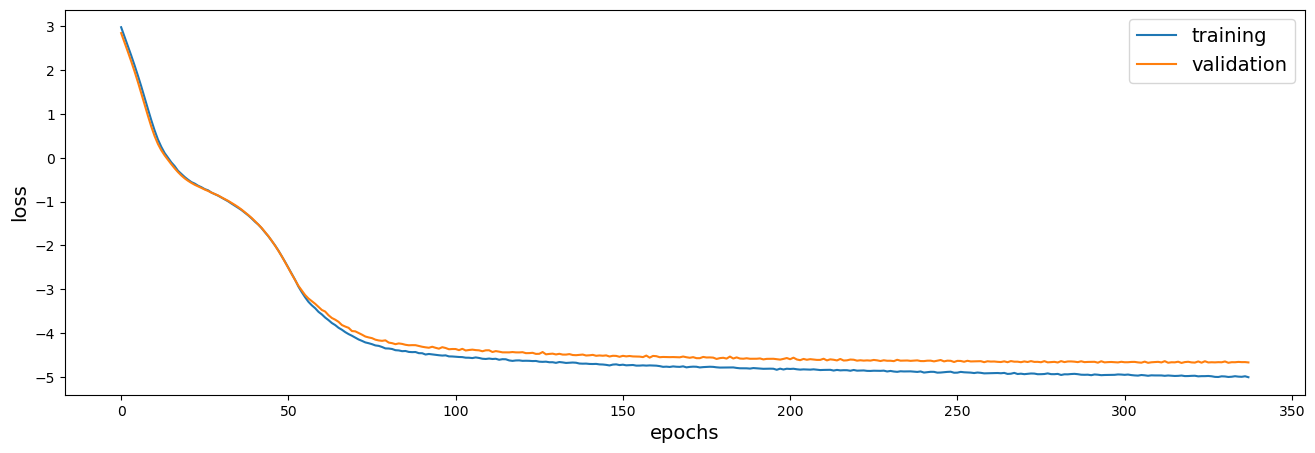

In [15]:
inferer = inferer.append_simulations(theta.to(device), x.to(device))
density_estimator = inferer.train(training_batch_size=1024)
posterior_summary = inferer.build_posterior(density_estimator)

fontsize = 14
plt.figure(figsize=(16, 5))
plt.plot(inferer.summary["training_loss"])
plt.plot(inferer.summary["validation_loss"])
plt.xlabel("epochs", fontsize=fontsize)
plt.ylabel("loss", fontsize=fontsize)
plt.legend(["training", "validation"], fontsize=fontsize)

The trained MAF estimates the posterior $p(\theta\mid x)$.

For this synthetic example, use the parameter vector from the first simulation as the generating value and compute its observables as `x_truth`. In a real application, these observables would be calculated from measured data.

In [16]:
prior.to("cpu")
theta_truth = torch.tensor([[10, 0.02, 13, 0.06]])
observation_seed = 2024
print(theta_truth)
x_truth = simulator(
    theta_truth.squeeze(0), sim_type="observables", seed=observation_seed
).unsqueeze(0)
print_summary(x_truth[0])

tensor([[10.0000,  0.0200, 13.0000,  0.0600]])


mean_pos_N=array([15., 15., 15.])
mean_pos_T=array([14., 20.,  0.])
conf_radius_N=array([25.4558, 26.1725, 26.4008])
conf_radius_T=array([35.5106, 53.4883, 53.0754])
num_normal_cells=np.float64(723.0)
num_tumor_cells=np.float64(851.0)


Because NPE learns an amortized posterior, we can condition it on `x_truth` and sample from $p(\theta\mid x=x_o)$:

In [17]:
num_samples = 10000
npe_posterior_samples_summary = posterior_summary.sample((num_samples,), x=x_truth.to(device))

  0%|          | 0/10000 [00:00<?, ?it/s]

Use `sbi`'s `pairplot` utility to compare the prior, posterior samples, and generating parameter vector. Concentration near the generating value is encouraging, but posterior calibration and predictive checks are also needed to assess correctness.

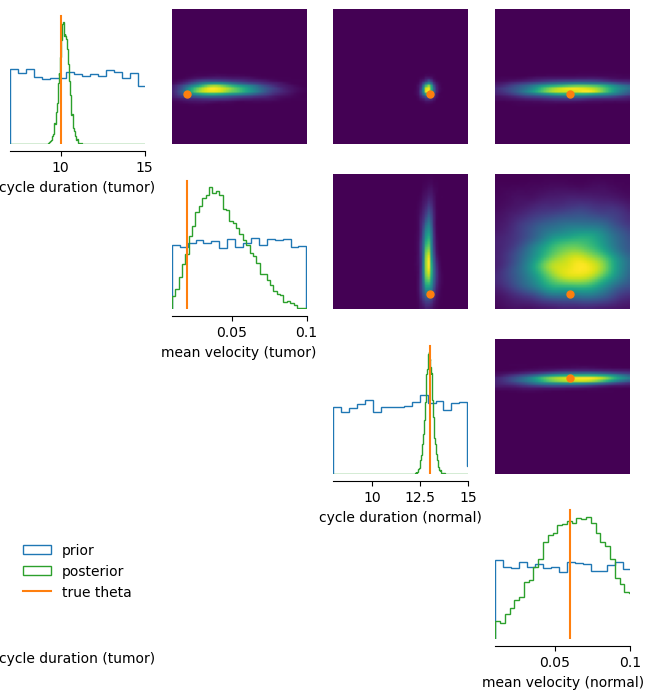

In [18]:
limits = torch.stack([low,high]).T
pairplot(
        [theta, npe_posterior_samples_summary.cpu()],
        limits=limits,
        points=theta_truth.cpu(),
        labels=[
            "cycle duration (tumor)",
            "mean velocity (tumor)",
            "cycle duration (normal)",
            "mean velocity (normal)",
        ],
        upper="kde",
        figsize=(8, 8),
        fig_kwargs={"samples_labels": ["prior", "posterior"],
                    "points_labels": ["true theta"],
                    "legend": True,
                   },
    )
plt.show()

## Comparison with image output

### Generating the dataset for training the posterior estimator

Generate a new training set in which each simulator output is the three-channel image introduced above.

In [19]:
prior, simul = initialize_sbi(low, high,sim_type="image")

Initializing the BoxUniform prior on the CPU.
4 parameters to be estimated.


In [20]:
%%time 
num_simulations=5000
theta_im, x_im = simulate_for_sbi(simul, prior, num_simulations=num_simulations, num_workers=workers)

  0%|          | 0/5000 [00:00<?, ?it/s]

CPU times: user 27.4 s, sys: 2.29 s, total: 29.7 s
Wall time: 5min 17s


The simulator output $x$ is now a batch of images:

In [21]:
# New simulations are already normalized. This check also supports legacy
# precomputed datasets that stored RGB intensities on the 0--255 scale.
x_im = x_im.to(torch.float32)
if x_im.max() > 1.0:
    x_im = x_im / 255.0

print(f"Image range: [{x_im.min().item():.3f}, {x_im.max().item():.3f}]")
theta_im.shape, x_im.shape

Image range: [0.000, 1.000]


(torch.Size([5000, 4]), torch.Size([5000, 65, 65, 3]))

Display several simulations for parameters sampled from the prior:

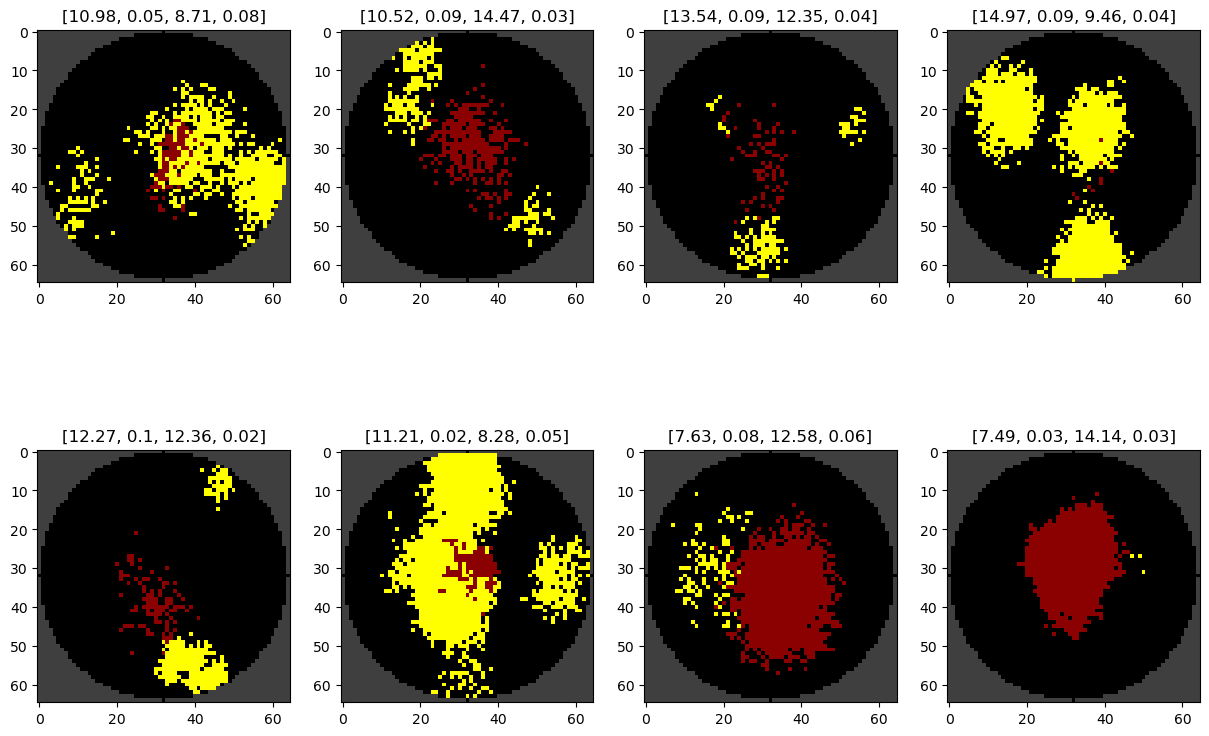

In [22]:
plt.figure(figsize=(15,10))
for i in range(0,8):
    title = [round(xi,2) for xi in theta_im[i].tolist()]
    plt.subplot(2,4,i+1)
    plt.title(title)
    plt.imshow(x_im[i])
plt.show()

### Training the posterior NN

Define the CNN embedding and train the posterior estimator. We use a small architecture for clarity; its layers and output dimension can be customized.

In [23]:
embedding_net = CNNEmbedding(input_shape=(65, 65),
                                             out_channels_per_layer = [3,3],
                                             num_conv_layers=2,
                                             kernel_size=3,
                                             in_channels=3,
                                             num_linear_layers = 1,
                                             num_linear_units = 28,
                                             pool_kernel_size=4,
                                             output_dim=14)
neural_posterior_with_CNN = posterior_nn(model="maf", embedding_net=embedding_net)

/p/scratch/training2637/venv/lib/python3.13/site-packages/sbi/inference/trainers/npe/npe_base.py:211: UserWarning: Data has constant values in dimension(s) [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 25

 Neural network successfully converged after 532 epochs.

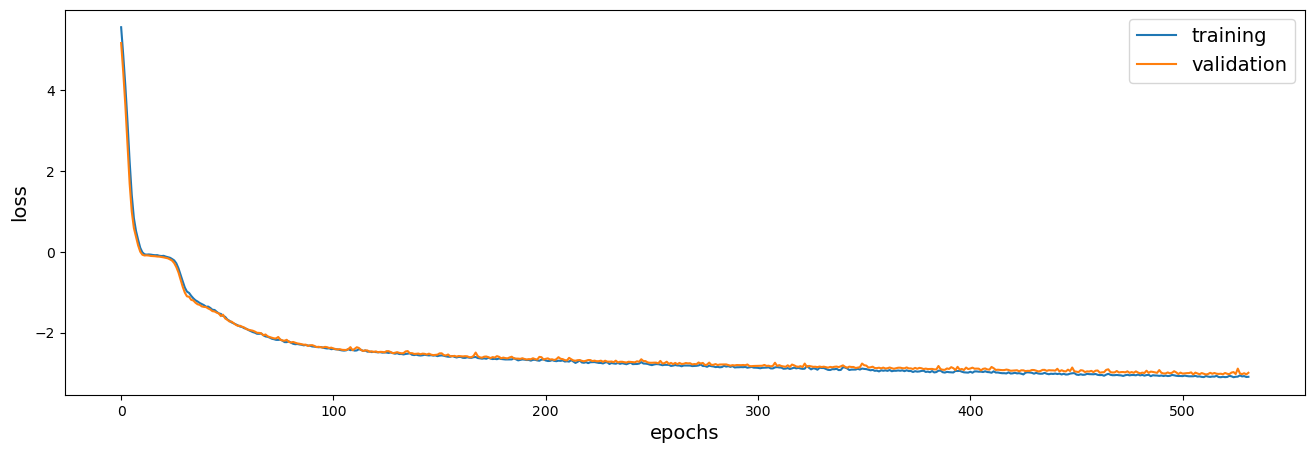

In [24]:
# PyTorch convolutions expect channels-first images: (batch, channels, height, width).
x_im_cnn = x_im.permute(0, 3, 1, 2).contiguous()

prior.to(device)
inferer = NPE(prior, density_estimator=neural_posterior_with_CNN, device=device)
density_estimator = inferer.append_simulations(theta_im.to(device), x_im_cnn.to(device)).train(training_batch_size=512)
posterior = inferer.build_posterior(density_estimator)

fontsize = 14
plt.figure(figsize=(16, 5))
plt.plot(inferer.summary["training_loss"])
plt.plot(inferer.summary["validation_loss"])
plt.xlabel("epochs", fontsize=fontsize)
plt.ylabel("loss", fontsize=fontsize)
plt.legend(["training", "validation"], fontsize=fontsize)

  0%|          | 0/10000 [00:00<?, ?it/s]

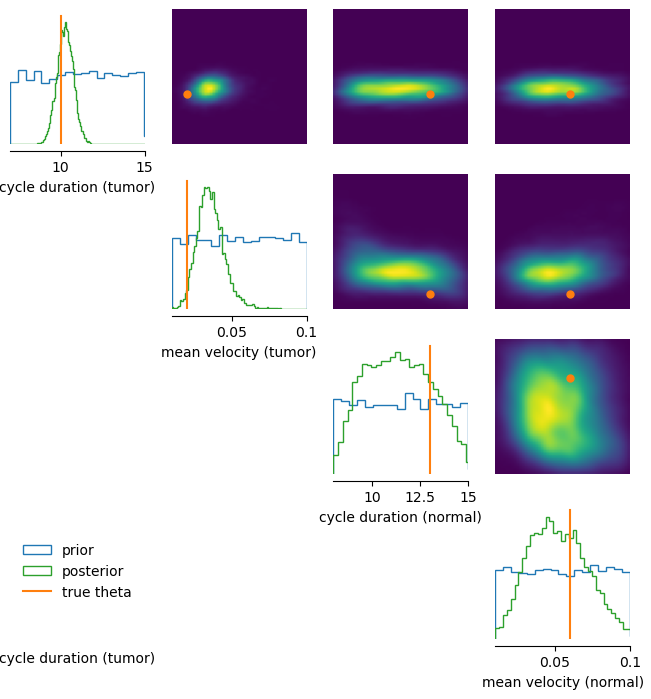

In [25]:
# Generate the image for the same parameter vector and random realization
# used for the observables-based inference above.
x_o_hwc = simulator(
    theta_truth.squeeze(0), sim_type="image", seed=observation_seed
).unsqueeze(0)
x_o = x_o_hwc.permute(0, 3, 1, 2).contiguous()

num_samples = 10000
npe_posterior_samples = posterior.set_default_x(x_o.to(device)).sample((num_samples,))

limits = torch.stack([low,high]).T
pairplot(
        [theta_im, npe_posterior_samples.cpu()],
        limits=limits,
        points=theta_truth.cpu(),
        labels=[
            "cycle duration (tumor)",
            "mean velocity (tumor)",
            "cycle duration (normal)",
            "mean velocity (normal)",
        ],
        upper="kde",
        figsize=(8, 8),
        fig_kwargs={"samples_labels": ["prior", "posterior"],
                    "points_labels": ["true theta"],
                    "legend": True,
                   },
    )
plt.show()

### Posterior predictive check

Simulating at the posterior mean is not a posterior predictive check: for a nonlinear simulator, the output at the mean parameter generally differs from the mean predictive output. Instead, draw parameter values from the posterior, simulate a new realization for each draw, and compare those replicated images with the observation. Systematic visual discrepancies indicate that the inferred posterior and simulator do not reproduce important features of the observed image.

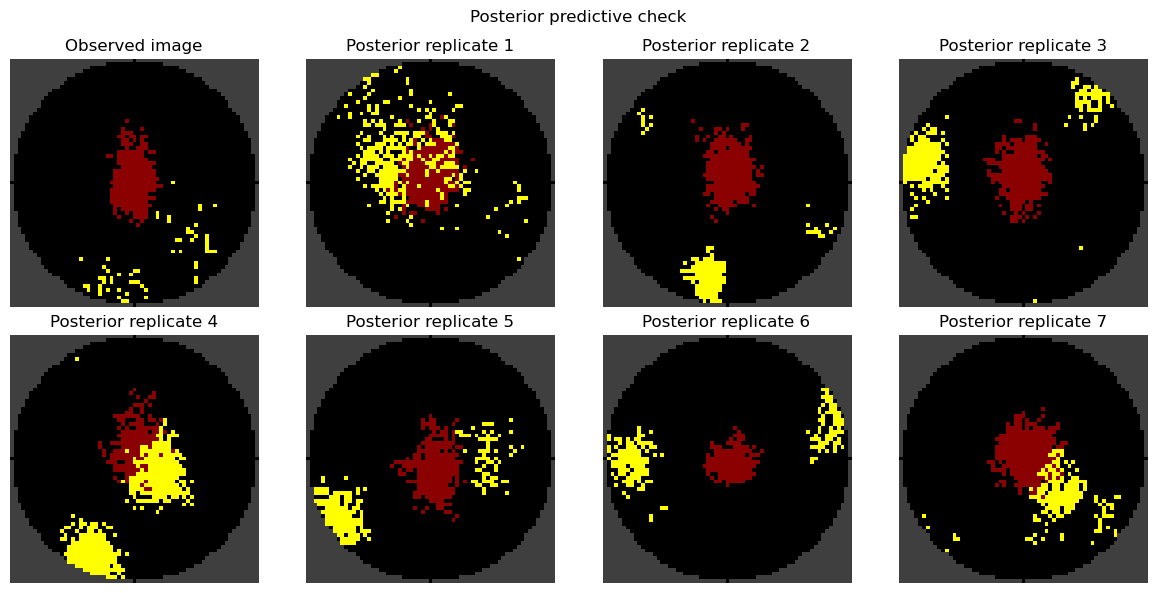

In [26]:
# Posterior predictive check: simulate replicated images from posterior draws.
num_ppc = 7
theta_ppc = npe_posterior_samples[:num_ppc].cpu()
x_ppc = torch.stack([
    simulator(theta, sim_type="image") for theta in theta_ppc
])

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()
axes[0].imshow(x_o_hwc.squeeze(0))
axes[0].set_title("Observed image")
for i, image in enumerate(x_ppc, start=1):
    axes[i].imshow(image)
    axes[i].set_title(f"Posterior replicate {i}")
for ax in axes:
    ax.axis("off")
fig.suptitle("Posterior predictive check")
fig.tight_layout()
plt.show()

### Calibration diagnostics

A pair plot for one synthetic observation does not establish that the posterior is reliable. We therefore evaluate the amortized image posterior on independently simulated parameter–image pairs. For each pair, the rank of the generating parameter among posterior samples should be approximately uniform. The empirical 90% credible-interval coverage should also be close to 90%. With the small diagnostic sample used here, interpret deviations as warning signs rather than definitive failures.

  0%|          | 0/50 [00:00<?, ?it/s]

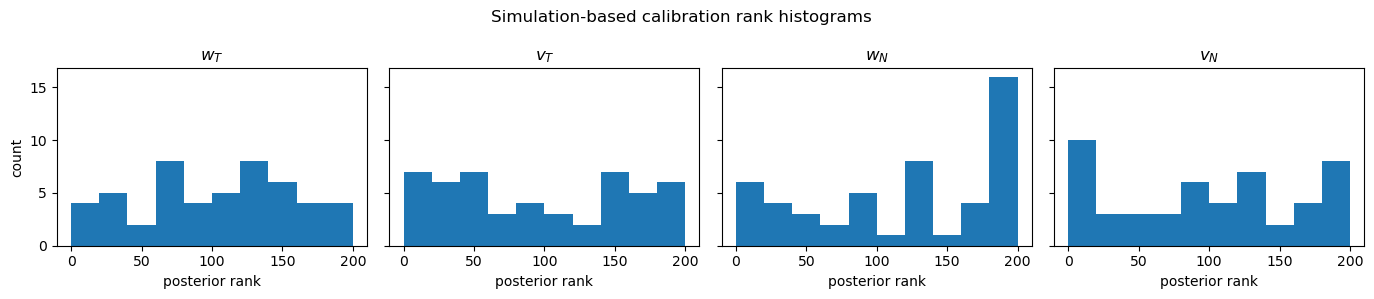

90% coverage for $w_T$: 0.88
90% coverage for $v_T$: 0.84
90% coverage for $w_N$: 0.70
90% coverage for $v_N$: 0.78


In [27]:
num_calibration = 50
num_calibration_samples = 200

calibration_prior = BoxUniform(low=low, high=high)
theta_cal, x_cal_hwc = simulate_for_sbi(
    simul, calibration_prior, num_simulations=num_calibration, num_workers=workers
)
x_cal = x_cal_hwc.to(torch.float32)
if x_cal.max() > 1.0:
    x_cal = x_cal / 255.0
x_cal = x_cal.permute(0, 3, 1, 2).contiguous()

ranks = torch.empty((num_calibration, theta_cal.shape[1]), dtype=torch.long)
covered_90 = torch.empty((num_calibration, theta_cal.shape[1]), dtype=torch.bool)
for i in range(num_calibration):
    samples = posterior.sample(
        (num_calibration_samples,), x=x_cal[i].to(device), show_progress_bars=False
    ).cpu()
    ranks[i] = (samples < theta_cal[i]).sum(dim=0)
    lower = torch.quantile(samples, 0.05, dim=0)
    upper = torch.quantile(samples, 0.95, dim=0)
    covered_90[i] = (theta_cal[i] >= lower) & (theta_cal[i] <= upper)

parameter_labels = ["$w_T$", "$v_T$", "$w_N$", "$v_N$"]
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for j, ax in enumerate(axes):
    ax.hist(ranks[:, j].numpy(), bins=10, range=(0, num_calibration_samples))
    ax.set_title(parameter_labels[j])
    ax.set_xlabel("posterior rank")
axes[0].set_ylabel("count")
fig.suptitle("Simulation-based calibration rank histograms")
fig.tight_layout()
plt.show()

coverage = covered_90.float().mean(dim=0)
for label, value in zip(parameter_labels, coverage):
    print(f"90% coverage for {label}: {value.item():.2f}")